In [9]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

### Historical data

In [27]:
url_hist = "https://archive-api.open-meteo.com/v1/era5"

latitude = 52.52    # Berlin
longitude = 13.405
start_date = "2025-05-01"
end_date = "2025-05-10"
time_zone = "Europe/Berlin"

hourly_params = ["temperature_2m,wind_speed_10m","apparent_temperature", "is_day"]

params_hist = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": hourly_params,
    "timezone": time_zone
}

response = requests.get(url_hist, params=params_hist)
data_hist = response.json()

In [28]:
df_hist = pd.DataFrame(data_hist['hourly'])

df_hist["timestamp"] = pd.to_datetime(df_hist["time"])
df_hist.set_index("timestamp", inplace=True)

df_hist.head()

,time,temperature_2m,wind_speed_10m,apparent_temperature,is_day
timestamp,,,,,
2025-05-01 00:00:00,2025-05-01T00:00,15.0,7.2,14.0,0
2025-05-01 01:00:00,2025-05-01T01:00,14.1,6.2,13.3,0
2025-05-01 02:00:00,2025-05-01T02:00,13.2,4.4,12.6,0
2025-05-01 03:00:00,2025-05-01T03:00,11.1,4.0,10.1,0
2025-05-01 04:00:00,2025-05-01T04:00,10.5,2.4,9.7,0


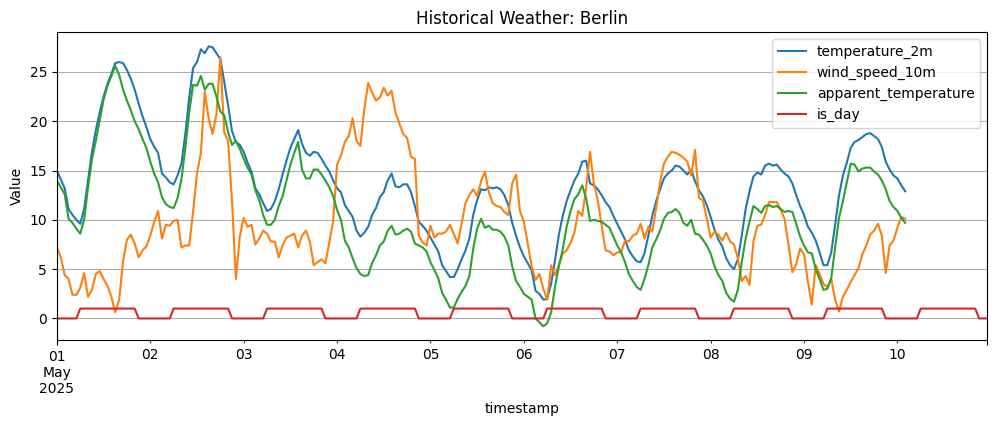

In [29]:
df_hist.plot(title="Historical Weather: Berlin", figsize=(12, 4))
plt.ylabel("Value")
plt.grid()
plt.show()

### Forecast data

In [ ]:
url = "https://api.open-meteo.com/v1/forecast"

latitude = 52.52    # Berlin
longitude = 13.405

params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": "temperature_2m,wind_speed_10m",
    "start_date": "2025-05-12",
    "end_date": "2025-05-15",
    "timezone": "Europe/Berlin"
}

In [7]:
response = requests.get(url, params=params)
data = response.json()

In [8]:

# Convert to DataFrame
df = pd.DataFrame({
    "timestamp": data["hourly"]["time"],
    "temperature_2m": data["hourly"]["temperature_2m"],
    "wind_speed_10m": data["hourly"]["wind_speed_10m"]
})

df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)
df.head()

,temperature_2m,wind_speed_10m
timestamp,,
2025-05-12 00:00:00,10.1,12.9
2025-05-12 01:00:00,8.9,10.5
2025-05-12 02:00:00,8.2,9.0
2025-05-12 03:00:00,7.7,7.6
2025-05-12 04:00:00,7.1,6.8


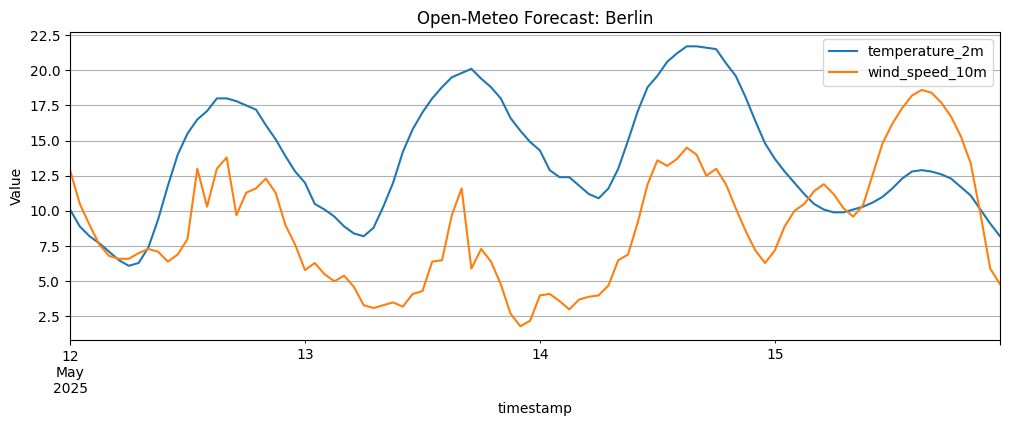

In [10]:
df.plot(title="Open-Meteo Forecast: Berlin", figsize=(12, 4))
plt.ylabel("Value")
plt.grid()
plt.show()